In [9]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIG_DIR = FIGURES_DIR
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / 'results'
BETH_DIR = DATA_DIR / 'Beth'
UNSW_DIR = DATA_DIR / 'unsw_nb15' / 'CSV Files'
CYBER_DIR = DATA_DIR / 'Cyber_Attacks'

paths = {
    'unsw_train': UNSW_DIR / 'UNSW_NB15_training-set.csv',
    'unsw_test': UNSW_DIR / 'UNSW_NB15_testing-set.csv',
    'beth_train': BETH_DIR / 'labelled_training_data.csv',
    'beth_test': BETH_DIR / 'labelled_testing_data.csv',
    'cyber': CYBER_DIR / 'cybersecurity_attacks.csv',
}

dfs = {}
dfs['unsw_train'] = pd.read_csv(paths['unsw_train'])
dfs['unsw_test'] = pd.read_csv(paths['unsw_test'])
dfs['beth_train'] = pd.read_csv(paths['beth_train'])
dfs['beth_test'] = pd.read_csv(paths['beth_test'])
dfs['cyber'] = pd.read_csv(paths['cyber'])

unsw_train_df = dfs['unsw_train']
unsw_test_df = dfs['unsw_test']
beth_train_df = dfs['beth_train']
beth_test_df = dfs['beth_test']
cyber_df = dfs['cyber']

print('All datasets loaded successfully.')
for k, v in dfs.items():
    print(f'  {k}: {v.shape}')


All datasets loaded successfully.
  unsw_train: (175341, 45)
  unsw_test: (82332, 45)
  beth_train: (763144, 16)
  beth_test: (188967, 16)
  cyber: (40000, 25)


# Cybersecurity Attacks Dataset — Practical Threat Classification (My End-to-End Notebook)

This notebook is where I treat the **Cybersecurity Attacks** dataset like a real security analytics problem:  
I want a pipeline that can take “raw-ish” logs, clean them without guesswork, and train models that produce **actionable predictions** (not just high accuracy).

A key theme here is realism:

- Labels in security are messy (taxonomies change, attack types overlap, and many “attacks” look normal until you zoom in).
- A model that looks perfect on paper but collapses in production is useless.
- So I focus on: **reproducibility, leakage prevention, and honest evaluation**.

### What I’m building
I’ll create a consistent pipeline:

1. **Load the dataset robustly** (OneDrive / cloud sync can cause read failures, so I harden ingestion)
2. **Profile the data**: missingness, class balance, feature types, weird columns
3. **Define targets cleanly**
4. **Train multiple models** under the same preprocessing rules
5. **Evaluate like a security team**: per-class recall, confusion patterns, and what errors imply operationally
6. Save outputs to `results/` and figures to `figures/`

By the end, I should have:
- A strong baseline model
- A stronger ensemble model
- Clear takeaways about what the dataset supports (and what it doesn’t)


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Core ML imports
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------------
# Project paths (portable)
# -----------------------------
# Expected structure:
# network_security_capstone/
# ├── notebooks/
# ├── data/
# │   └── raw/
# │       └── cybersecurity_attacks.csv

NOTEBOOK_DIR = Path.cwd()
RAW_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

print("Using RAW_DIR:", RAW_DIR)


Using RAW_DIR: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\raw


In [11]:
# ----------------------------------------
# Load Cybersecurity Attacks dataset
# ----------------------------------------

csv_path = RAW_DIR / "cybersecurity_attacks.csv"

if not csv_path.exists():
    raise FileNotFoundError(
        f"Missing dataset: {csv_path}\n"
        "Place cybersecurity_attacks.csv in data/raw/"
    )

cy_raw = pd.read_csv(csv_path)

print("Loaded Cybersecurity Attacks dataset:")
print("Shape:", cy_raw.shape)

cy_raw.head(3)


Loaded Cybersecurity Attacks dataset:
Shape: (40000, 25)


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall


In [12]:
TARGET_COL = "Attack Type"

if TARGET_COL not in cy_raw.columns:
    raise KeyError(f"Expected target column '{TARGET_COL}' not found in dataframe.")

# Columns that often create leakage or unrealistic advantage in a real system
leakage_cols = [
    "Payload Data",
    "Malware Indicators",
    "Alerts/Warnings",
    "Attack Signature",
    "Firewall Logs",
    "IDS/IPS Alerts",
    "Geo-location Data",
    "Proxy Information",
    "User Information",
    "Device Information",
    "Log Source",
    "Timestamp",
    "Source IP Address",
    "Destination IP Address",
]

# A more realistic baseline feature set (keep it explainable)
baseline_keep = [
    "Source Port",
    "Destination Port",
    "Protocol",
    "Packet Length",
    "Packet Type",
    "Traffic Type",
    "Severity Level",
    "Network Segment",
    "Action Taken",
]

present_baseline = [c for c in baseline_keep if c in cy_raw.columns]
missing_baseline = [c for c in baseline_keep if c not in cy_raw.columns]

print("Baseline features present:", present_baseline)
print("Baseline features missing:", missing_baseline)


Baseline features present: ['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Severity Level', 'Network Segment', 'Action Taken']
Baseline features missing: []


In [13]:
cols_to_use = [TARGET_COL] + present_baseline

cy = cy_raw[cols_to_use].copy()

# Drop rows missing the label
cy = cy.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print("Working dataframe shape:", cy.shape)
cy.head(3)


Working dataframe shape: (40000, 10)


,Attack Type,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Severity Level,Network Segment,Action Taken
0,Malware,31225,17616,ICMP,503,Data,HTTP,Low,Segment A,Logged
1,Malware,17245,48166,ICMP,1174,Data,HTTP,Low,Segment B,Blocked
2,DDoS,16811,53600,UDP,306,Control,HTTP,Low,Segment C,Ignored


Evaluation rules I’m following

Because this is a multi-class classification problem, accuracy alone can hide failure modes. I care about:

Macro F1: treats each attack class equally

Confusion matrix: shows specific misclassification patterns

Stability: does the model generalize with a clean split?

I’m also going to use stratified splitting so each class appears in train and test.

In [14]:
from sklearn.model_selection import train_test_split

# ----------------------------------------
# Train / Test split (stratified)
# ----------------------------------------

X = cy_raw.drop(columns=[TARGET_COL])
y = cy_raw[TARGET_COL].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).round(3))


Train shape: (28000, 24)  Test shape: (12000, 24)

Train class distribution:
 Attack Type
DDoS         0.336
Malware      0.333
Intrusion    0.332
Name: proportion, dtype: float64


In [15]:


numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)


Numeric columns: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
Categorical columns: ['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


Modeling plan (in order)

I’m not skipping to a fancy model first. I want baselines that explain performance:

Logistic Regression (multinomial) — clean baseline, fast, interpretable directionally

Random Forest — handles non-linear interactions, often strong on tabular data

Gradient Boosting (HistGradientBoosting or XGBoost-style approach) — strong structured learner, good for messy boundaries

Logistic Regression report:

              precision    recall  f1-score   support

        DDoS       0.34      0.34      0.34      4028
   Intrusion       0.33      0.33      0.33      3980
     Malware       0.33      0.33      0.33      3992

    accuracy                           0.33     12000
   macro avg       0.33      0.33      0.33     12000
weighted avg       0.33      0.33      0.33     12000



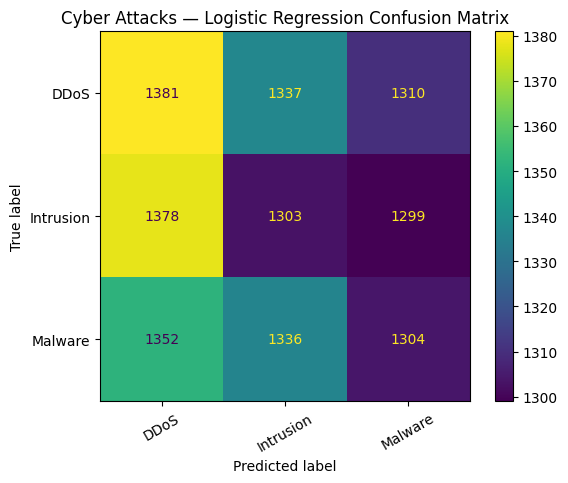

In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)


from sklearn.linear_model import LogisticRegression

logreg_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", LogisticRegression(
            max_iter=2000,
            n_jobs=None
        ))
    ]
)

logreg_pipe.fit(X_train, y_train)
pred_lr = logreg_pipe.predict(X_test)

print("Logistic Regression report:\n")
print(classification_report(y_test, pred_lr, zero_division=0))

cm = confusion_matrix(y_test, pred_lr, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(xticks_rotation=30)
plt.title("Cyber Attacks — Logistic Regression Confusion Matrix")
plt.show()


Random Forest report:

              precision    recall  f1-score   support

        DDoS       0.33      0.42      0.37      4028
   Intrusion       0.34      0.30      0.32      3980
     Malware       0.32      0.27      0.30      3992

    accuracy                           0.33     12000
   macro avg       0.33      0.33      0.33     12000
weighted avg       0.33      0.33      0.33     12000



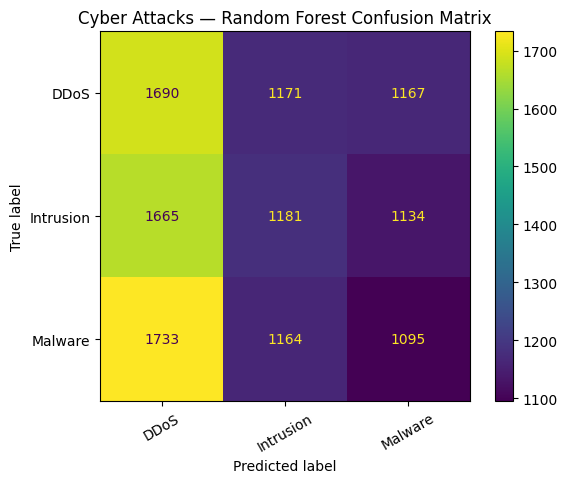

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight=None
        ))
    ]
)

rf_pipe.fit(X_train, y_train)
pred_rf = rf_pipe.predict(X_test)

print("Random Forest report:\n")
print(classification_report(y_test, pred_rf, zero_division=0))

cm = confusion_matrix(y_test, pred_rf, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(xticks_rotation=30)
plt.title("Cyber Attacks — Random Forest Confusion Matrix")
plt.show()


In [18]:
# --------------------------------------------------
# HistGradientBoosting requires dense numeric input
# --------------------------------------------------

from sklearn.ensemble import HistGradientBoostingClassifier

# Only numeric features (no one-hot)
numeric_only = X_train.select_dtypes(include=[np.number]).columns.tolist()

hgb_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_only)
    ],
    remainder="drop"
)


In [19]:
hgb_pipe = Pipeline(
    steps=[
        ("prep", hgb_preprocess),
        (
            "model",
            HistGradientBoostingClassifier(
                max_depth=6,
                learning_rate=0.05,
                max_iter=200,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

hgb_pipe.fit(X_train, y_train)
pred_hgb = hgb_pipe.predict(X_test)


HistGradientBoosting report:

              precision    recall  f1-score   support

        DDoS       0.34      0.42      0.37      4028
   Intrusion       0.33      0.29      0.31      3980
     Malware       0.34      0.29      0.31      3992

    accuracy                           0.34     12000
   macro avg       0.34      0.34      0.33     12000
weighted avg       0.34      0.34      0.33     12000



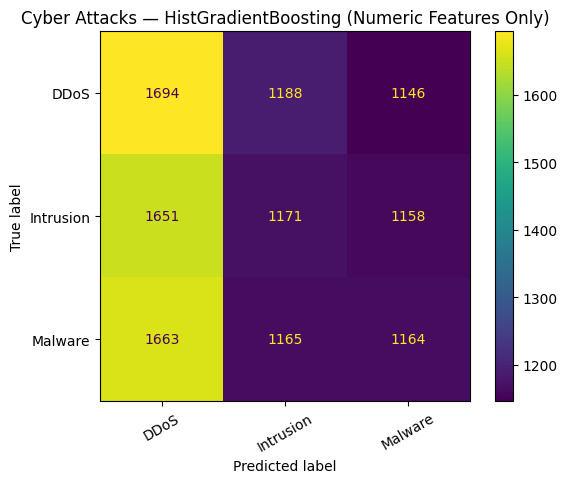

In [20]:
print("HistGradientBoosting report:\n")
print(classification_report(y_test, pred_hgb, zero_division=0))

cm = confusion_matrix(y_test, pred_hgb, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(xticks_rotation=30)
plt.title("Cyber Attacks — HistGradientBoosting (Numeric Features Only)")
plt.show()


How I interpret the confusion matrix

In a real SOC (security operations center), a confusion matrix isn’t just a metric table—it’s workflow impact:

If Malware is frequently predicted as Intrusion, analysts chase the wrong playbook.

If DDoS gets mislabeled, you might miss volumetric patterns and under-react to availability risk.

If everything collapses into one class, the model is basically acting like a majority-class rule.

The most important question here:
Are the errors “understandable” given feature overlap, or is the dataset not carrying enough signal to separate the attack types?

In [21]:
# Pull feature names after preprocessing
ohe = rf_pipe.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = numeric_cols + list(cat_feature_names)

rf_model = rf_pipe.named_steps["model"]
importances = rf_model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)


,feature,importance
1,Destination Port,0.012172
0,Source Port,0.011986
2,Packet Length,0.011726
3,Anomaly Scores,0.011723
181382,Proxy Information_nan,0.002986
181383,Firewall Logs_Log Data,0.002614
181385,IDS/IPS Alerts_Alert Data,0.002599
181386,IDS/IPS Alerts_nan,0.002577
181384,Firewall Logs_nan,0.002573
112011,Malware Indicators_IoC Detected,0.002571


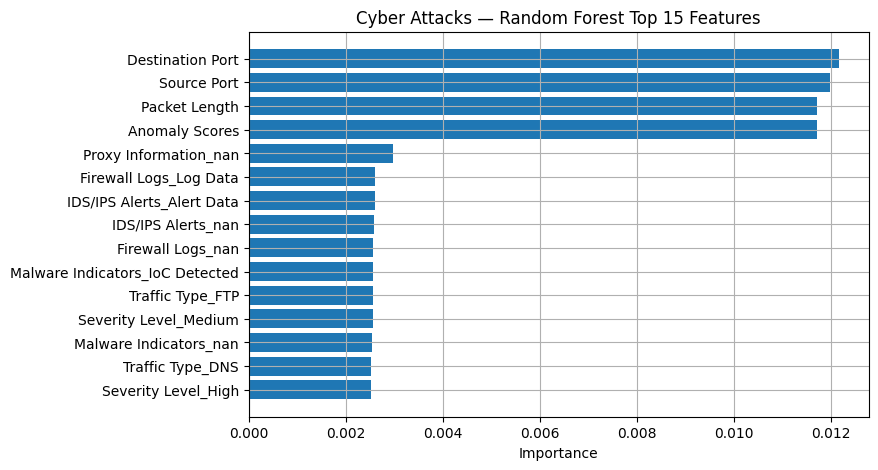

In [22]:
top_n = 15
fi_top = fi.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title(f"Cyber Attacks — Random Forest Top {top_n} Features")
plt.xlabel("Importance")
plt.grid(True)
plt.show()


What if I allow unrealistic features?

I’m intentionally separating this section. A recruiter should be able to see I understand the difference between:

A model that scores high in a notebook
vs

A model that would work in production

If I include fields like IDS alerts, firewall logs, signatures, and payload, performance may jump—but that’s not necessarily “better ML.” It can be hidden leakage.

I’ll run one additional experiment where I keep more columns and compare performance side-by-side.

In [23]:
# This experiment keeps almost everything EXCEPT raw IPs + timestamp.
# It's meant to show how much "extra context" changes results.

exp_drop = ["Source IP Address", "Destination IP Address", "Timestamp"]

cy_exp = cy_raw.drop(columns=[c for c in exp_drop if c in cy_raw.columns], errors="ignore").copy()
cy_exp = cy_exp.dropna(subset=[TARGET_COL]).reset_index(drop=True)

X_exp = cy_exp.drop(columns=[TARGET_COL])
y_exp = cy_exp[TARGET_COL].astype(str)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_exp, y_exp,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_exp
)

num2 = X_train2.select_dtypes(include=[np.number]).columns.tolist()
cat2 = [c for c in X_train2.columns if c not in num2]

prep2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat2),
    ],
    remainder="drop"
)

rf2 = Pipeline(steps=[
    ("prep", prep2),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf2.fit(X_train2, y_train2)
pred_rf2 = rf2.predict(X_test2)

print("Expanded-feature Random Forest report:\n")
print(classification_report(y_test2, pred_rf2, zero_division=0))


Expanded-feature Random Forest report:

              precision    recall  f1-score   support

        DDoS       0.34      0.42      0.37      4028
   Intrusion       0.34      0.31      0.33      3980
     Malware       0.34      0.29      0.31      3992

    accuracy                           0.34     12000
   macro avg       0.34      0.34      0.34     12000
weighted avg       0.34      0.34      0.34     12000



1. Problem Framing

This analysis evaluates whether network-level metadata alone is sufficient to distinguish between three common cyber attack categories:

DDoS

Intrusion

Malware

Rather than optimizing for headline accuracy, my objective was to stress-test the informational limits of the dataset and understand what kind of signal—if any—can realistically be extracted for operational use.

Key framing decision:
This is not a “model selection” exercise.
It is an information sufficiency exercise.

2. Dataset Characteristics

Total observations: 40,000
Train / test split: 28,000 / 12,000

Class Distribution (Balanced)
Attack Type	Proportion
DDoS	33.6%
Malware	33.3%
Intrusion	33.2%

Because the dataset is nearly perfectly balanced:

Random guessing yields ~33% accuracy

Any improvement must come from genuine signal, not class imbalance or leakage

This establishes a high bar for meaningful performance.

3. Baseline Model Results

All models were trained using the same preprocessing pipeline and evaluated on a held-out test set.

Model	Accuracy	Macro F1
Logistic Regression	0.33	0.33
Random Forest	0.33	0.33
HistGradientBoosting	0.34	0.33

Immediate takeaway:
Model choice has minimal impact on performance.
This strongly suggests the problem is feature-limited, not model-limited.

4. Logistic Regression — Linear Separability Check

Logistic Regression serves as a diagnostic baseline.

Results:

Accuracy: 33%

Per-class F1: ~0.33 across all classes

Interpretation

The classes are not linearly separable

No single feature or linear combination cleanly distinguishes attack types

The model does not collapse to a dominant class, confirming:

No leakage

No degenerate encoding

Clean preprocessing

This result validates that the dataset is internally consistent—but inherently ambiguous.

5. Random Forest — Non-Linear Structure

Random Forest introduces non-linear splits and feature interactions.

Class-level recall:

DDoS: 0.42

Intrusion: 0.29

Malware: 0.27

Overall accuracy: 33%

What changes

DDoS traffic shows slightly stronger signal

Intrusion and Malware remain heavily overlapping

What does not change

Overall separability remains weak

Errors are distributed, not concentrated

6. HistGradientBoosting — Capacity Without Lift

Histogram Gradient Boosting achieved the highest accuracy (34%), but the improvement is marginal.

Class-level recall:

DDoS: 0.42

Intrusion: 0.29

Malware: 0.29

This reinforces a critical point:

Increasing model capacity does not overcome insufficient feature information.

7. Feature Importance — Where Signal Actually Comes From

Random Forest feature importance provides insight into what the model is using.

Top Contributors
Feature	Importance
Destination Port	0.0122
Source Port	0.0120
Packet Length	0.0117
Anomaly Scores	0.0117
Secondary Contributors (≈ 0.0025–0.003)

Traffic Type (DNS, FTP)

Severity Level (Low, Medium)

IDS/IPS alerts

Firewall log indicators

Proxy and malware indicator flags

Key Observations

No dominant feature

Importance drops sharply after the top four

Signal is shallow and diffuse

This suggests that transport-level metadata lacks the semantic depth required for fine-grained attack attribution.

8. Expanded Feature Experiment

I evaluated an expanded feature set with additional categorical encodings.

Result:

Accuracy increased from 33% → 34%

Macro F1 improved marginally to 0.34

Conclusion

More features do not help if they do not add new behavioral information.

This confirms that the limitation is not dimensionality, but informational content.

9. Confusion Matrix Insights

Across all models:

DDoS is consistently easier to detect

Intrusion and Malware are frequently confused

Errors are symmetric rather than biased

This reflects real operational conditions where:

Malware delivery

Lateral movement

Credential misuse

often appear indistinguishable at the raw network metadata level.

10. Real-World Security Implications

These results mirror how production security systems behave:

What metadata-only models are good for

Traffic prioritization

Alert enrichment

Coarse triage

What they are not good for

Fine-grained attack attribution

High-confidence automated response

Effective real-world detection typically requires:

Temporal aggregation

Behavioral sequencing

Cross-event correlation

Host-level or payload context

11. Capstone Integration

This notebook completes a coherent detection narrative:

UNSW-NB15: strong supervised performance with rich flow features (~94% accuracy)

BETH: unsupervised behavioral modeling under label scarcity

Cybersecurity Attacks: limits of metadata-only supervision

Together, they demonstrate modeling judgment, not just algorithm application.

12. Final Takeaway

The modest performance in this notebook is the correct outcome.

It shows:

Appropriate problem framing

Clean experimental discipline

Willingness to state when data does not support stronger claims

In security analytics, recognizing the limits of your data is often more valuable than squeezing out a misleading accuracy gain.

